In [7]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt

In [8]:
orig_icc_res = pd.read_csv('./log/orig_icc_res.csv')

In [9]:
orig_icc_res

,pair,pconfig,pmetric,pscalar,pstrict,scale
0,V_GP,0.000,NaN,NaN,NaN,anhedonic_depression
1,V_EN,0.956,0.002,NaN,NaN,anhedonic_depression
2,GP_EN,0.144,0.033,NaN,NaN,anhedonic_depression
3,V_GP,0.210,0.006,NaN,NaN,anxious_worry
4,V_EN,0.961,0.041,NaN,NaN,anxious_worry
5,GP_EN,0.099,0.000,NaN,NaN,anxious_worry
6,V_GP,0.939,0.007,NaN,NaN,appetite_gain
7,V_EN,0.871,0.086,0.100,1.0,appetite_gain
8,GP_EN,0.738,0.818,0.121,1.0,appetite_gain
9,V_GP,0.081,0.953,0.438,1.0,appetite_loss


In [10]:
palette = sns.color_palette('Pastel1', 8)

In [11]:
palette

[(0.984313725490196, 0.7058823529411765, 0.6823529411764706),
 (0.7019607843137254, 0.803921568627451, 0.8901960784313725),
 (0.8, 0.9215686274509803, 0.7725490196078432),
 (0.8705882352941177, 0.796078431372549, 0.8941176470588236),
 (0.996078431372549, 0.8509803921568627, 0.6509803921568628),
 (1.0, 1.0, 0.8),
 (0.8980392156862745, 0.8470588235294118, 0.7411764705882353),
 (0.9921568627450981, 0.8549019607843137, 0.9254901960784314)]

In [12]:
colors = [palette[0], palette[5], palette[4], palette[1],  palette[2]]

In [13]:
to_plot = orig_icc_res.set_index(['scale', 'pair']).isnull().sum(axis=1).reset_index().pivot(index='scale', columns='pair', values=0)
to_plot = to_plot.reset_index()
to_plot['scale'] = to_plot.scale.str.replace('_', ' ').str.title()
to_plot['scale'] = to_plot.scale.replace('Shame Guilt', 'Shame/Guilt')
to_plot['scale'] = to_plot.scale.replace('Well Being', 'Well-Being')
to_plot = to_plot.rename(columns={'scale':'Scale'})
to_plot = to_plot.set_index('Scale')
to_plot.columns.name = 'Data Pairs'
to_plot = to_plot.rename(columns={'GP_EN':'GenPop\nEnriched', 'V_EN':'OG Valid\nEnriched', 'V_GP':'OG Valid\nGenPop'})

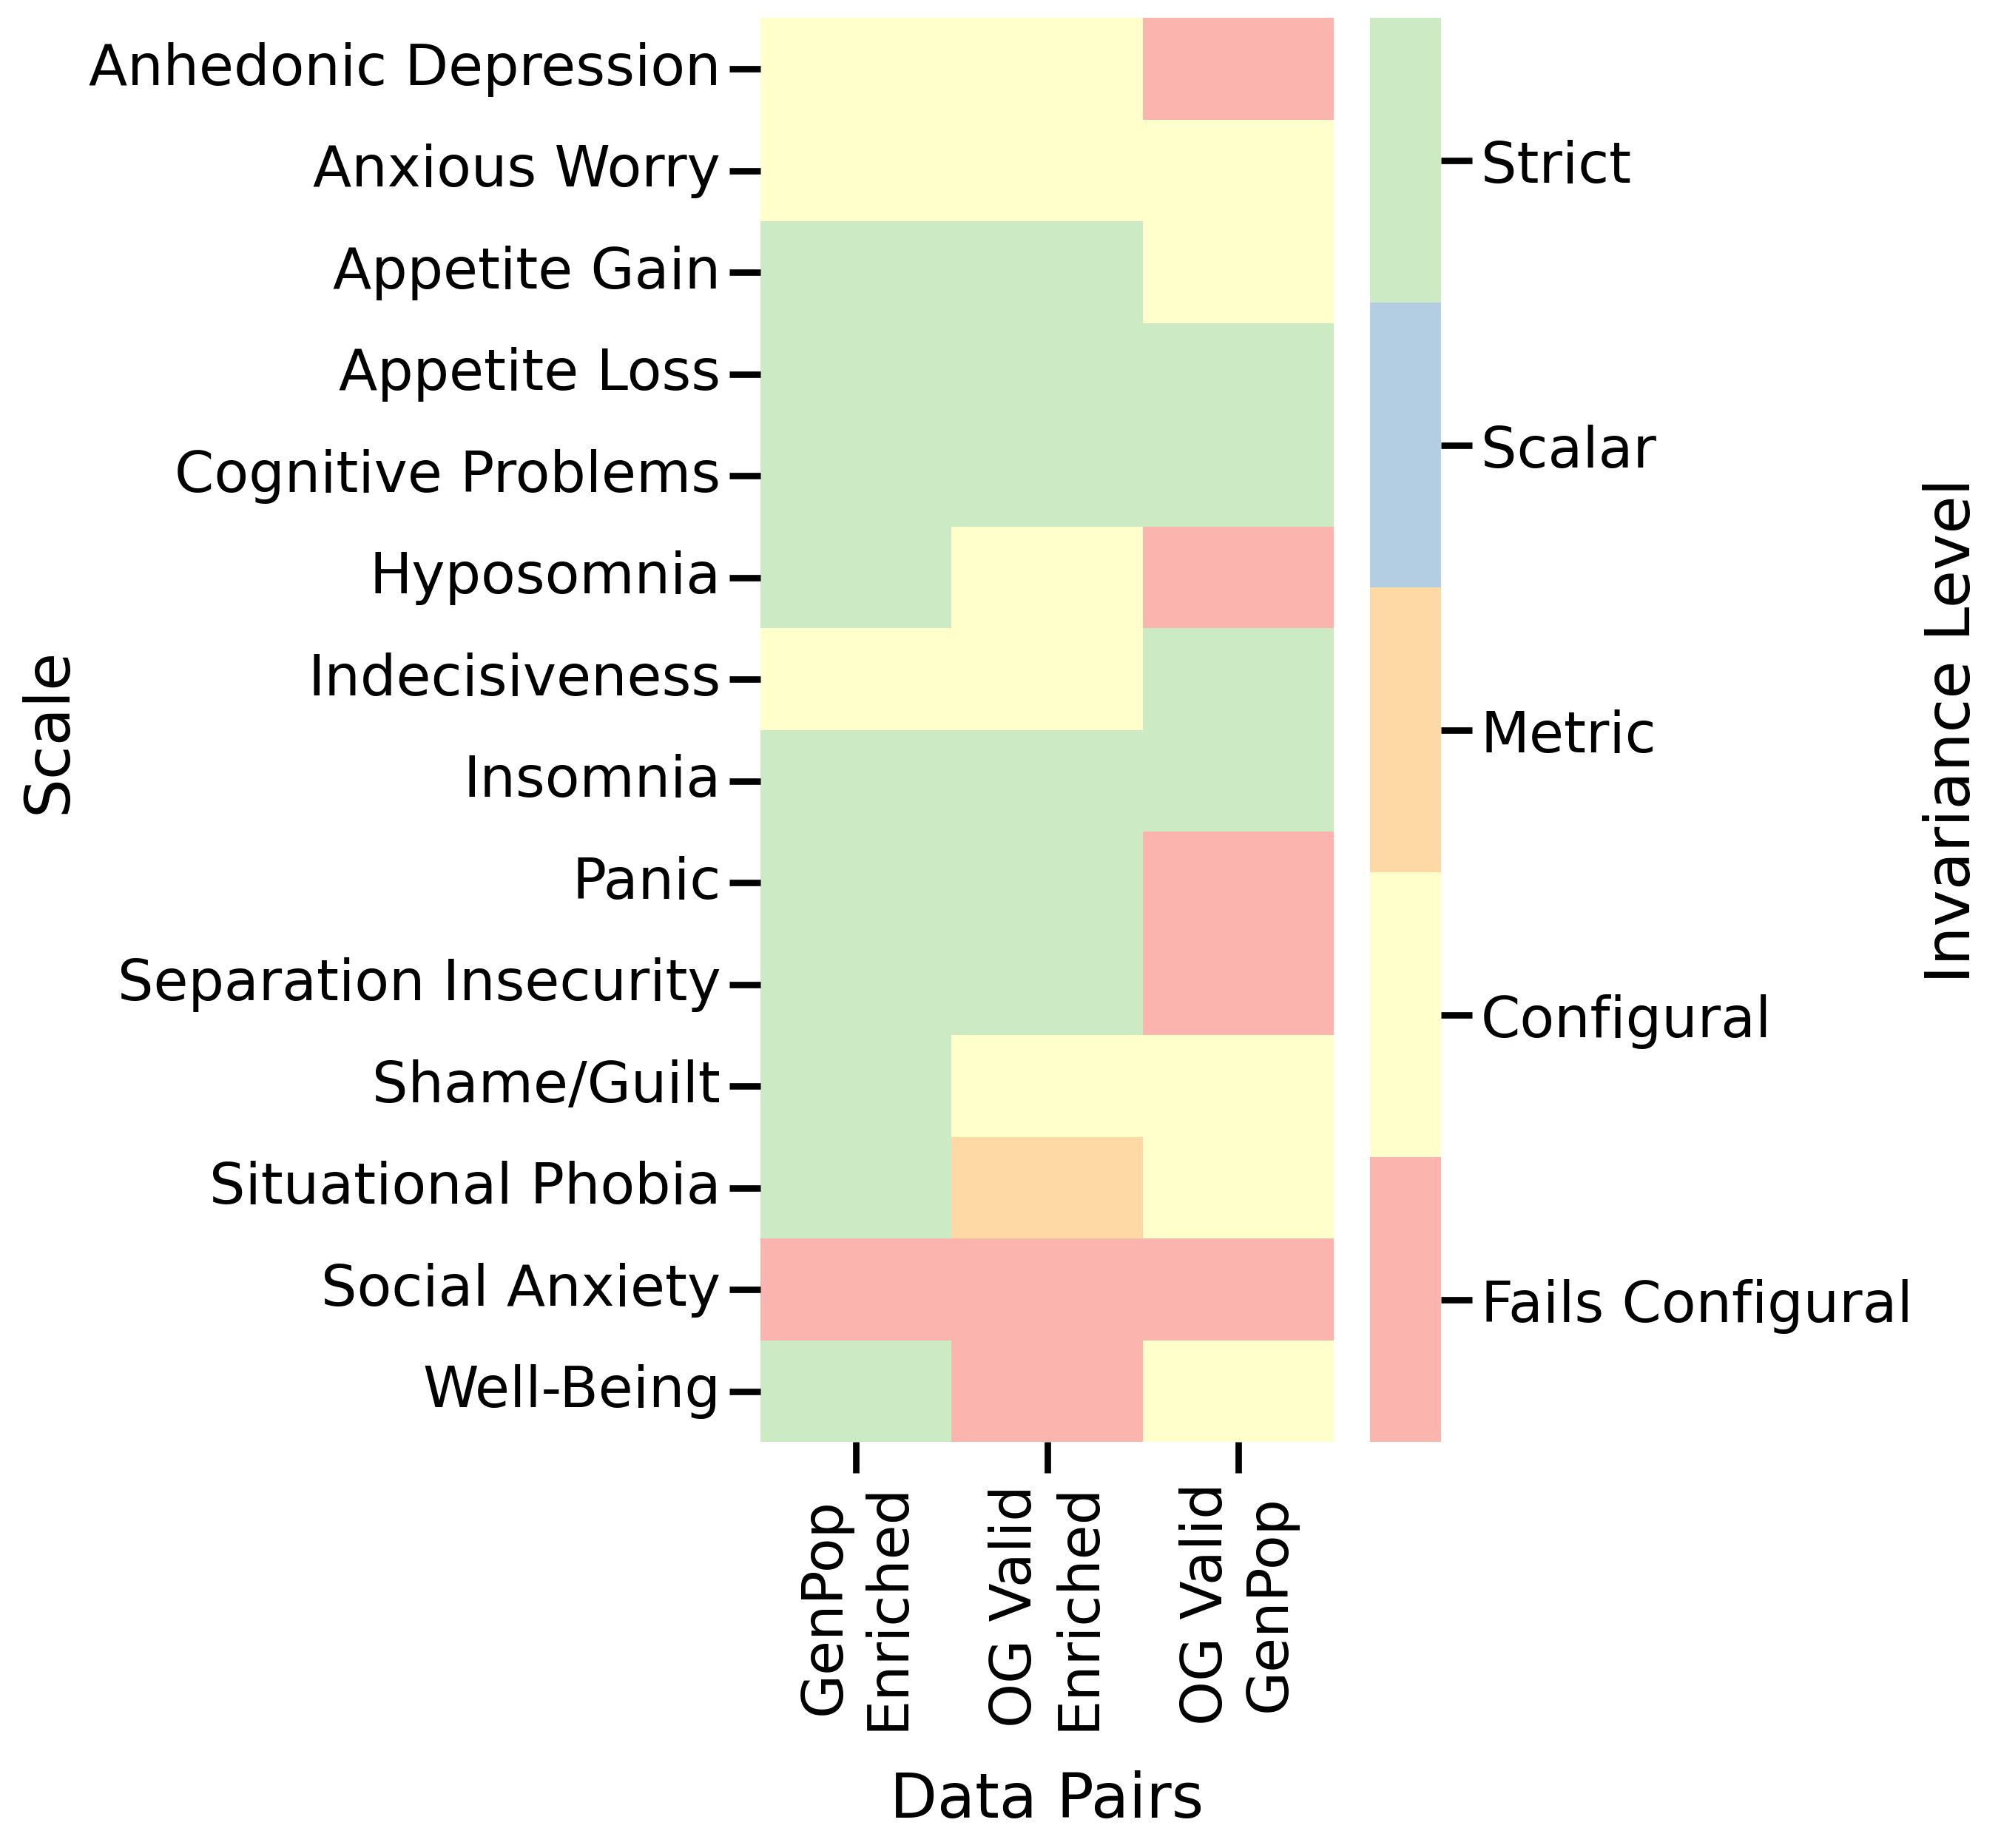

In [14]:
sns.set_context('poster')
to_plot = to_plot.replace({1:5, 0:9, 3:1})
fig, ax = plt.subplots(1, figsize=(5,10), dpi=250)
sns.heatmap(to_plot, cmap=colors, vmax=10, vmin=0)
colorbar = ax.collections[0].colorbar 
colorbar.set_ticks([1, 3, 5, 7, 9])
colorbar.set_ticklabels(['Fails Configural', 'Configural', 'Metric', 'Scalar', 'Strict'])
colorbar.set_label('Invariance Level')
ax.xaxis.set_label_coords(0.5, -0.23) 


In [76]:
ax.xaxis.get_label()

Text(0.5, 42.999999999999986, 'Data Pairs')

In [39]:
to_plot

pair,GP_EN,V_EN,V_GP
scale,,,
anhedonic_depression,2,2,3
anxious_worry,2,5,2
appetite_gain,5,5,2
appetite_loss,5,5,5
cognitive_problems,5,5,5
hyposomnia,5,2,3
indecisiveness,2,2,5
insomnia,5,5,5
panic,5,5,3


In [15]:
stepwise = pd.read_pickle('../data/cfa/stepwise.pkl')

In [18]:
for row in stepwise.itertuples():
    print(row.scale)
    print(row.removed)
    print()

anhedonic_depression
['It felt like there wasn’t anything interesting or fun to do.', 'I had very little energy.', 'It took a lot of effort to do everyday activities.']

anxious_worry
nan

appetite_gain
['I thought a lot about food.']

hyposomnia
['I felt like I could keep going and going without ever getting tired.']

panic
['I was trembling or shaking.']

separation_insecurity
['I wanted someone else to make decisions for me.', 'I could not stand being alone.']

situational_phobia
['I was afraid of the dark.', 'I was afraid of heights.']

shame_guilt
['I felt guilty.']

social_anxiety
['I felt shy around other people.', 'I felt socially awkward.', 'I felt uncomfortable being the center of attention.', 'I felt self-conscious around others.', 'I avoided performing or giving a talk in front of others.', 'I had difficulty making eye contact with others.', 'I was uncomfortable meeting new people.']

well_being
['I was proud of myself.', 'It was easy for me to laugh.', 'I looked forward to